In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sqlalchemy import create_engine, text
import warnings
warnings.filterwarnings('ignore')

print("✔ Library siap!")

✔ Library siap!


In [2]:
# Load CSV
df = pd.read_csv("df_final_panel.csv")
print("✔ Data berhasil diload!")
print(f"Shape: {df.shape}")
print(df.head())

✔ Data berhasil diload!
Shape: (175, 6)
           kabupaten_kota  tahun  kemiskinan_pct    ipm   tpt   pdrb
0  3301 KABUPATEN CILACAP   2020           11.46  69.95  9.10 -10.28
1  3301 KABUPATEN CILACAP   2021           11.67  70.42  9.97   2.15
2  3301 KABUPATEN CILACAP   2022           11.02  70.99  9.62   5.15
3  3301 KABUPATEN CILACAP   2023           10.99  71.83  8.74   5.32
4  3301 KABUPATEN CILACAP   2024           10.68  72.38  7.83   2.70


In [3]:
# Buat database SQLite
engine = create_engine("sqlite:///ekonomi_jateng.db")

# Simpan dataframe ke database
df.to_sql("ekonomi", engine, if_exists="replace", index=False)
print("✔ Data berhasil disimpan ke database SQLite!")

✔ Data berhasil disimpan ke database SQLite!


In [4]:
query = """
SELECT 
    COUNT(*) as total_observasi,
    COUNT(DISTINCT kabupaten_kota) as total_kabkota,
    COUNT(DISTINCT tahun) as total_tahun,
    ROUND(AVG(kemiskinan_pct), 2) as avg_kemiskinan,
    ROUND(AVG(ipm), 2) as avg_ipm,
    ROUND(AVG(tpt), 2) as avg_tpt,
    ROUND(AVG(pdrb), 2) as avg_pdrb
FROM ekonomi
"""

hasil = pd.read_sql(query, engine)
print("===== STATISTIK DESKRIPTIF =====")
print(hasil.to_string(index=False))

===== STATISTIK DESKRIPTIF =====
 total_observasi  total_kabkota  total_tahun  avg_kemiskinan  avg_ipm  avg_tpt  avg_pdrb
             175             35            5            10.7    73.56      5.4      3.38


In [5]:
query = """
SELECT 
    tahun,
    ROUND(AVG(kemiskinan_pct), 2) as avg_kemiskinan,
    ROUND(AVG(ipm), 2) as avg_ipm,
    ROUND(AVG(tpt), 2) as avg_tpt,
    ROUND(AVG(pdrb), 2) as avg_pdrb
FROM ekonomi
GROUP BY tahun
ORDER BY tahun
"""

df_tahun = pd.read_sql(query, engine)
print("===== RATA-RATA PER TAHUN =====")
print(df_tahun.to_string(index=False))

===== RATA-RATA PER TAHUN =====
 tahun  avg_kemiskinan  avg_ipm  avg_tpt  avg_pdrb
  2020           11.01    72.51     6.40     -1.94
  2021           11.39    72.85     5.87      3.50
  2022           10.58    73.50     5.35      5.39
  2023           10.40    74.17     4.86      4.97
  2024           10.13    74.75     4.52      4.98


In [6]:
query = """
SELECT 
    kabupaten_kota,
    ROUND(AVG(kemiskinan_pct), 2) as avg_kemiskinan,
    ROUND(AVG(ipm), 2) as avg_ipm,
    ROUND(AVG(tpt), 2) as avg_tpt
FROM ekonomi
GROUP BY kabupaten_kota
ORDER BY avg_kemiskinan DESC
LIMIT 10
"""

df_miskin = pd.read_sql(query, engine)
print("===== TOP 10 TERMISKIN =====")
print(df_miskin.to_string(index=False))

===== TOP 10 TERMISKIN =====
             kabupaten_kota  avg_kemiskinan  avg_ipm  avg_tpt
     3305 KABUPATEN KEBUMEN           16.78    70.79     5.64
    3307 KABUPATEN WONOSOBO           16.41    68.95     4.92
      3329 KABUPATEN BREBES           16.38    67.17     9.28
    3327 KABUPATEN PEMALANG           15.52    67.33     6.83
3304 KABUPATEN BANJARNEGARA           15.34    68.53     5.99
 3303 KABUPATEN PURBALINGGA           15.32    69.72     5.59
     3317 KABUPATEN REMBANG           14.85    71.17     3.14
      3314 KABUPATEN SRAGEN           13.09    74.66     4.32
    3302 KABUPATEN BANYUMAS           12.85    73.19     6.13
      3310 KABUPATEN KLATEN           12.61    76.88     4.68


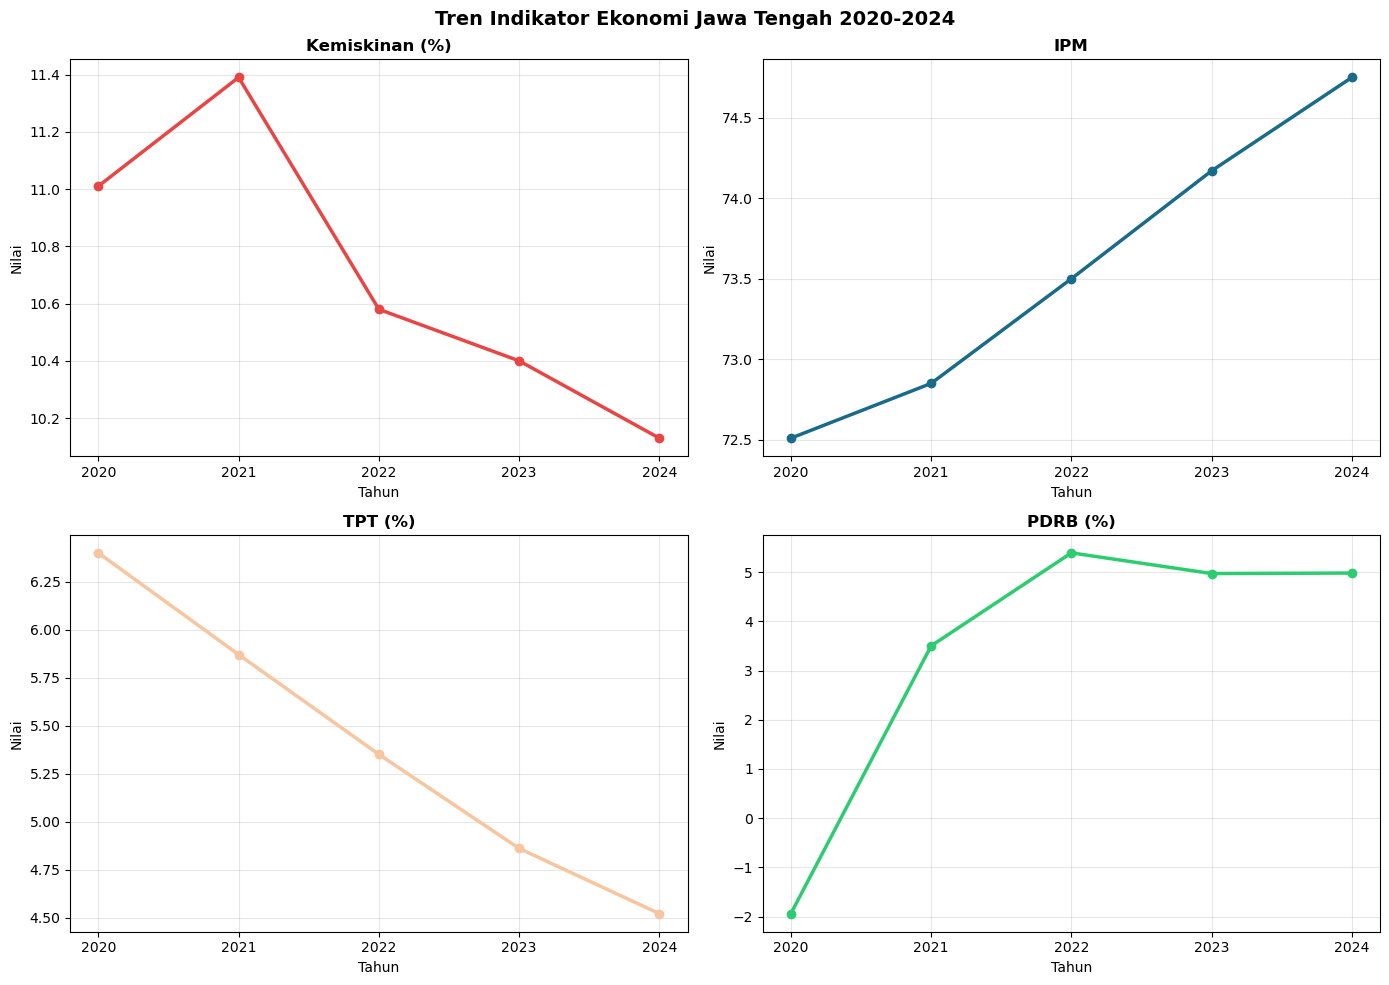

✔ Plot tersimpan!


In [7]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("Tren Indikator Ekonomi Jawa Tengah 2020-2024",
             fontsize=14, fontweight="bold")

indikator = ["avg_kemiskinan", "avg_ipm", "avg_tpt", "avg_pdrb"]
judul     = ["Kemiskinan (%)", "IPM", "TPT (%)", "PDRB (%)"]
warna     = ["#e84545", "#1a6b8a", "#f7c59f", "#2ecc71"]

for i, (ind, judul, warna) in enumerate(zip(indikator, judul, warna)):
    ax = axes[i//2][i%2]
    ax.plot(df_tahun["tahun"], df_tahun[ind],
            marker="o", linewidth=2.5, color=warna)
    ax.set_title(judul, fontweight="bold")
    ax.set_xlabel("Tahun")
    ax.set_ylabel("Nilai")
    ax.grid(True, alpha=0.3)
    ax.set_xticks(df_tahun["tahun"])

plt.tight_layout()
plt.savefig("plot_tren_python.png", dpi=150, bbox_inches="tight")
plt.show()
print("✔ Plot tersimpan!")

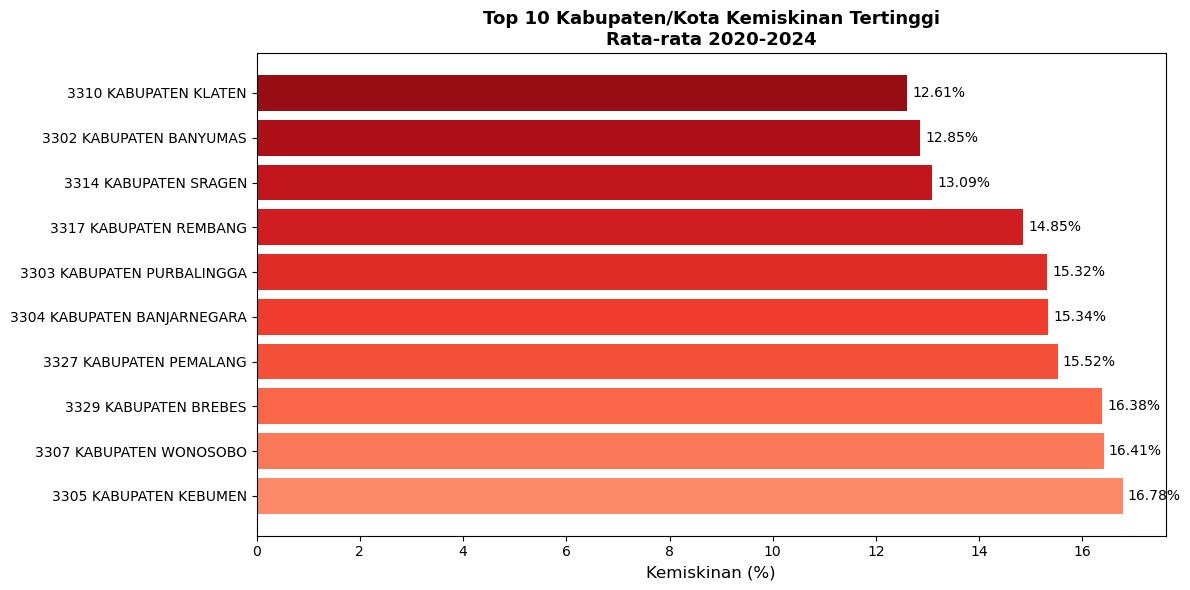

✔ Plot tersimpan!


In [8]:
plt.figure(figsize=(12, 6))
bars = plt.barh(df_miskin["kabupaten_kota"],
                df_miskin["avg_kemiskinan"],
                color=plt.cm.Reds(
                    np.linspace(0.4, 0.9, len(df_miskin))))

plt.xlabel("Kemiskinan (%)", fontsize=12)
plt.title("Top 10 Kabupaten/Kota Kemiskinan Tertinggi\nRata-rata 2020-2024",
          fontsize=13, fontweight="bold")

for bar, val in zip(bars, df_miskin["avg_kemiskinan"]):
    plt.text(bar.get_width() + 0.1, bar.get_y() + bar.get_height()/2,
             f"{val}%", va="center", fontsize=10)

plt.tight_layout()
plt.savefig("plot_termiskin_python.png", dpi=150, bbox_inches="tight")
plt.show()
print("✔ Plot tersimpan!")

In [9]:
print("=" * 50)
print("RINGKASAN PROJECT 3 - SQL + PYTHON")
print("=" * 50)
print(f"Total observasi   : {len(df)}")
print(f"Total kab/kota    : {df['kabupaten_kota'].nunique()}")
print(f"Periode           : {df['tahun'].min()} - {df['tahun'].max()}")
print(f"\nRata-rata Kemiskinan : {df['kemiskinan_pct'].mean():.2f}%")
print(f"Rata-rata IPM        : {df['ipm'].mean():.2f}")
print(f"Rata-rata TPT        : {df['tpt'].mean():.2f}%")
print(f"Rata-rata PDRB       : {df['pdrb'].mean():.2f}%")
print("\n✔ Project 3 Selesai!")

RINGKASAN PROJECT 3 - SQL + PYTHON
Total observasi   : 175
Total kab/kota    : 35
Periode           : 2020 - 2024

Rata-rata Kemiskinan : 10.70%
Rata-rata IPM        : 73.56
Rata-rata TPT        : 5.40%
Rata-rata PDRB       : 3.38%

✔ Project 3 Selesai!
